Shape of X: (500, 2)
Shape of y: (500,)
First 5 samples of X:
 [[ 0.83085779 -0.33434228]
 [ 0.99170955  0.87899966]
 [ 1.1072453  -0.47034376]
 [-0.14089918  1.03314844]
 [ 0.40559217  1.32852876]]
First 5 samples of y: [1 0 1 0 0]


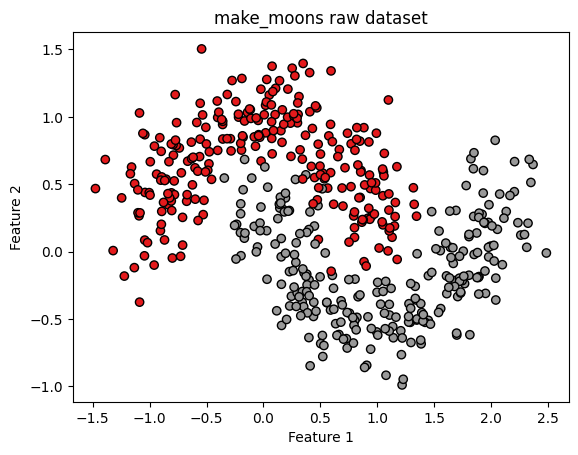

/home/ailab/anaconda3/lib/python3.10/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training accuracy: 0.995
Test accuracy: 0.97


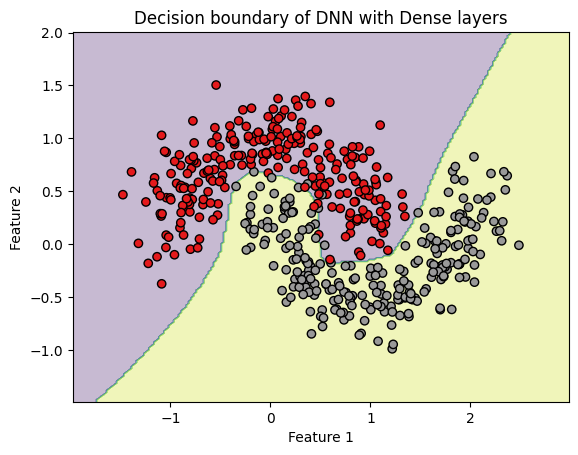

In [8]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


# Create dataset
X, y = make_moons(
    n_samples=500,
    noise=0.2,
    random_state=42
)

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)
print("First 5 samples of X:\n", X[:5])
print("First 5 samples of y:", y[:5])


plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap=plt.cm.Set1,
    edgecolor="k"
)

plt.title("make_moons raw dataset")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

model = Sequential([
    Dense(64, activation="relu", input_shape=(2,)),
    Dense(32, activation="relu", input_shape=(2,)),

    Dense(16, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=32,
    verbose=0
)

train_loss, train_acc = model.evaluate(
    X_train,
    y_train,
    verbose=0
)

test_loss, test_acc = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

print("Training accuracy:", round(train_acc, 3))
print("Test accuracy:", round(test_acc, 3))

xx, yy = np.meshgrid(
    np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200),
    np.linspace(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]
grid_scaled = scaler.transform(grid)

Z = model.predict(grid_scaled, verbose=0)

Z = (Z > 0.5).astype(int).reshape(xx.shape)

plt.contourf(
    xx,
    yy,
    Z,
    alpha=0.3
)

plt.scatter(
    X[:, 0],
    X[:, 1],
    c=y,
    cmap=plt.cm.Set1,
    edgecolor="k"
)

plt.title("Decision boundary of DNN with Dense layers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.show()